"""
BRANCH AND BOUND PARA EL PROBLEMA DEL VIAJANTE (TSP)

Objetivo:
Encontrar la ruta de menor costo que visite todas las ciudades
exactamente una vez y regrese al punto de partida.

Funcionamiento:

1. Branch:
   Se generan recursivamente todas las posibles extensiones
   de una ruta parcial.

2. Bound:
   Se calcula una estimación optimista del costo mínimo
   que podría alcanzar cada rama.

3. Poda:
   Si la estimación ya es peor que la mejor solución conocida,
   la rama se descarta sin seguir explorándola.

Ventajas:
- Garantiza encontrar la solución óptima.
- Explora muchas menos rutas que fuerza bruta.

Desventajas:
- El número de nodos crece rápidamente al aumentar ciudades.
- Depende mucho de la calidad de la cota utilizada.
"""

In [2]:
import math
import time
import matplotlib.pyplot as plt

In [3]:
ciudades = [

    # Grupo A
    (10,10),
    (12,11),
    (11,13),
    (14,12),

    # Grupo B
    (45,45),
    (47,46),
    (44,48),
    (46,50),

    # Grupo C
    (85,15),
    (88,18),
    (86,21),
    (90,17),

    # Ciudades puente
    (30,25),
    (60,30),

    # Ciudades conflictivas
    (55,70),
    (25,60)
]

cantidad_ciudades = len(ciudades)

print("Cantidad de ciudades:", cantidad_ciudades)

Cantidad de ciudades: 16


In [6]:
def distancia(p1, p2):
    return math.sqrt(
        (p1[0] - p2[0])**2 +
        (p1[1] - p2[1])**2
    )

matriz = []

for i in range(cantidad_ciudades):

    fila = []

    for j in range(cantidad_ciudades):

        if i == j:
            fila.append(0)

        else:
            fila.append(
                distancia(
                    ciudades[i],
                    ciudades[j]
                )
            )

    matriz.append(fila)

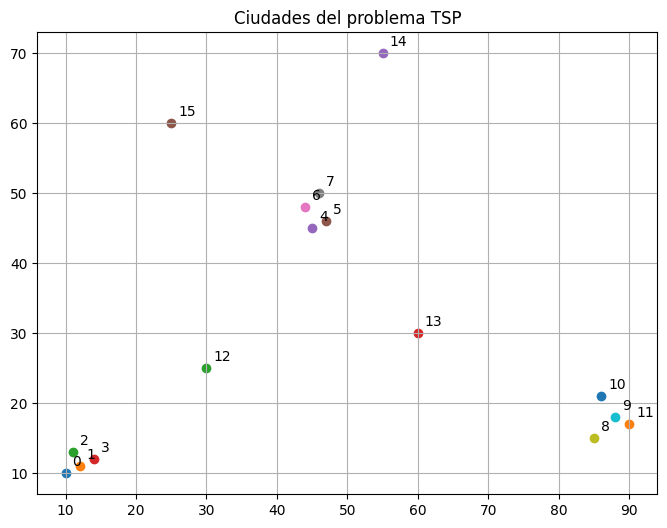

In [7]:
plt.figure(figsize=(8,6))

for indice, (x,y) in enumerate(ciudades):

    plt.scatter(x, y)

    plt.text(
        x + 1,
        y + 1,
        str(indice)
    )

plt.title("Ciudades del problema TSP")
plt.grid(True)

plt.show()

# Coordenadas (x,y) de cada ciudad.
# Se diseñaron grupos de ciudades cercanas entre sí para generar
# distintas regiones dentro del problema TSP.
#
# Los grupos A, B y C representan clusters bien definidos.
# Las ciudades puente ayudan a conectar regiones lejanas.
# Las ciudades conflictivas generan decisiones difíciles para el algoritmo,
# ya que pueden pertenecer a más de una ruta atractiva.

In [11]:
class Estadisticas:

    def __init__(self):

        self.nodos_explorados = 0
        self.nodos_podados = 0

# Clase utilizada para almacenar métricas de ejecución.
#
# Nodos explorados:
# Cantidad total de estados evaluados por Branch and Bound.
#
# Nodos podados:
# Cantidad de ramas descartadas gracias al cálculo de la cota.
#
# Estas métricas permiten evaluar la eficiencia del algoritmo.

In [8]:
def calcular_cota(
        ruta_actual,
        costo_actual,
        visitados,
        matriz):

    n = len(matriz)

    estimacion = costo_actual

    for ciudad in range(n):

        if ciudad not in visitados:

            menor = float('inf')

            for destino in range(n):

                if ciudad != destino:

                    if matriz[ciudad][destino] < menor:

                        menor = matriz[ciudad][destino]

            estimacion += menor

    return estimacion

# Calcula una cota inferior (Bound).
#
# La idea es estimar el menor costo posible que podría alcanzar
# la ruta actual si se completara de la mejor forma posible.
#
# Para cada ciudad aún no visitada se agrega su conexión más barata.
#
# Esta estimación NO es exacta, pero permite descartar muchas ramas
# que jamás podrán mejorar la mejor solución encontrada.

In [9]:
def branch_and_bound(matriz):

    n = len(matriz)

    mejor_costo = float('inf')

    mejor_ruta = None

    stats = Estadisticas()

    def explorar(
            ciudad_actual,
            visitados,
            ruta,
            costo_actual):

        nonlocal mejor_costo
        nonlocal mejor_ruta

        stats.nodos_explorados += 1

        if len(visitados) == n:

            costo_total = (
                costo_actual
                + matriz[ciudad_actual][0]
            )

            if costo_total < mejor_costo:

                mejor_costo = costo_total

                mejor_ruta = ruta[:] + [0]

            return

        limite = calcular_cota(
            ruta,
            costo_actual,
            visitados,
            matriz
        )

        if limite >= mejor_costo:

            stats.nodos_podados += 1
            return

        for siguiente in range(n):

            if siguiente not in visitados:

                explorar(
                    siguiente,
                    visitados | {siguiente},
                    ruta + [siguiente],
                    costo_actual +
                    matriz[ciudad_actual][siguiente]
                )

    explorar(
        0,
        {0},
        [0],
        0
    )

    return mejor_ruta, mejor_costo, stats

In [12]:
inicio = time.time()

ruta_bb, costo_bb, stats_bb = branch_and_bound(matriz)

fin = time.time()

tiempo_bb = fin - inicio

In [13]:
print("===== BRANCH AND BOUND =====\n")

print("Ruta encontrada:")
print(ruta_bb)

print("\nCosto total:")
print(round(costo_bb, 2))

print("\nNodos explorados:")
print(stats_bb.nodos_explorados)

print("\nNodos podados:")
print(stats_bb.nodos_podados)

print("\nTiempo:")
print(round(tiempo_bb, 4), "segundos")

===== BRANCH AND BOUND =====

Ruta encontrada:
[0, 1, 3, 12, 8, 11, 9, 10, 13, 5, 4, 6, 7, 14, 15, 2, 0]

Costo total:
254.33

Nodos explorados:
260288799

Nodos podados:
185553617

Tiempo:
1518.2864 segundos


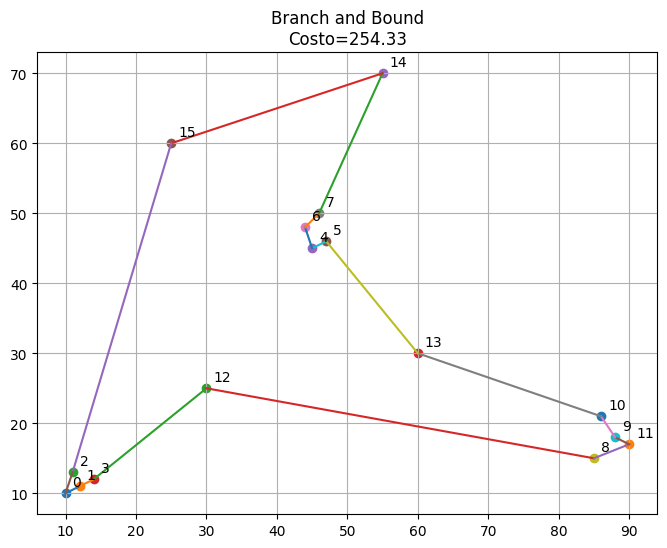

In [14]:
plt.figure(figsize=(8,6))

for i in range(len(ruta_bb)-1):

    origen = ruta_bb[i]
    destino = ruta_bb[i+1]

    x1,y1 = ciudades[origen]
    x2,y2 = ciudades[destino]

    plt.plot(
        [x1,x2],
        [y1,y2]
    )

for indice,(x,y) in enumerate(ciudades):

    plt.scatter(x,y)

    plt.text(
        x + 1,
        y + 1,
        str(indice)
    )

plt.title(
    f"Branch and Bound\nCosto={round(costo_bb,2)}"
)

plt.grid(True)

plt.show()

#Branch and Bound genera sistemáticamente todas las posibles soluciones mediante ramificación (Branch), pero utiliza una estimación del mejor costo posible (Bound) para descartar anticipadamente aquellas ramas que no pueden mejorar la solución actual. Gracias a este mecanismo de poda, encuentra la solución óptima explorando muchas menos combinaciones que una búsqueda exhaustiva.